In [68]:
# 自己写旋转坐标
import numpy as np
from numpy import sin,cos
def rotateX(vectors,angle):
    line,colum=vectors.shape
    vectors=np.concatenate([vectors,np.ones(shape=(1,colum))],axis=0)

    matrix=np.array([
        [cos(angle),-sin(angle),0,0],
        [sin(angle), cos(angle),0,0],
        [0            ,0,             1,0],
        [0            ,0,             0,0],
    ])
    return np.dot(matrix,vectors).T[:,:-1]
def rotateY(vectors,angle):
    line,colum=vectors.shape
    vectors=np.concatenate([vectors,np.ones(shape=(1,colum))],axis=0)

    matrix=np.array([
        [cos(angle),0,-sin(angle),0],
        [0,1,0,0],
        [sin(angle),0,cos(angle),0],
        [0,0,0,1],
    ])
    return np.dot(matrix,vectors).T[:,:-1]
def rotateZ(vectors,angle):
    line,colum=vectors.shape
    vectors=np.concatenate([vectors,np.ones(shape=(1,colum))],axis=0)

    matrix=np.array([
        [1,0,0,0],
        [0,cos(angle),-sin(angle),0],
        [0,sin(angle),cos(angle),0],
        [0,0,0,1],
    ])
    return np.dot(matrix,vectors).T[:,:-1]
def array2Str(array,atoms):
    lines=[]
    for i,each in enumerate(array):
        line=f'{atoms[i]} '+','.join([f'{p}' for p in each.tolist()])
        lines.append(line)
    return '\n'.join(lines)
        
cords=np.array([
    [ 0.00000000 ,  -0.67760000 ,   0.00000000],
    [ 0.92664718 ,  -1.21260000 ,   0.00000000],
    [-0.92664718 ,  -1.21260000 ,   0.00000000],
    [ 0.00000000 ,   0.67760000 ,   0.00000000],
    [-0.92664718 ,   1.21260000 ,   0.00000000],
    [ 0.92664718 ,   1.21260000 ,   0.00000000],
])
atoms='C,H,H,C,H,H'.split(',')
with open('template.txt','r',encoding='utf-8') as f:
    template=f.read()

In [69]:
for i in range(37):
    cordsCopy=cords.copy()
    cordsCopy[:3,:]=rotateY(cordsCopy[:3,:].T,i*np.pi/36)
    res=array2Str(cordsCopy,atoms)
    with open(f'scans/ethylene_{i}.gjf','w',encoding='utf-8') as f:
        f.write(template.replace('COORDINATES',res).replace('IDX',f'{i}'))

In [43]:
res=array2Str(rotateX(cords.T,1*np.pi/36),atoms)

C 0.05905673128581317,-0.6750215274269667,0.0
H 1.0288060613734777,-1.1272230676681276,0.0
H -0.8174359540618571,-1.2887483141439735,0.0
C -0.05905673128581317,0.6750215274269667,0.0
H -1.0288060613734777,1.1272230676681276,0.0
H 0.8174359540618571,1.2887483141439735,0.0


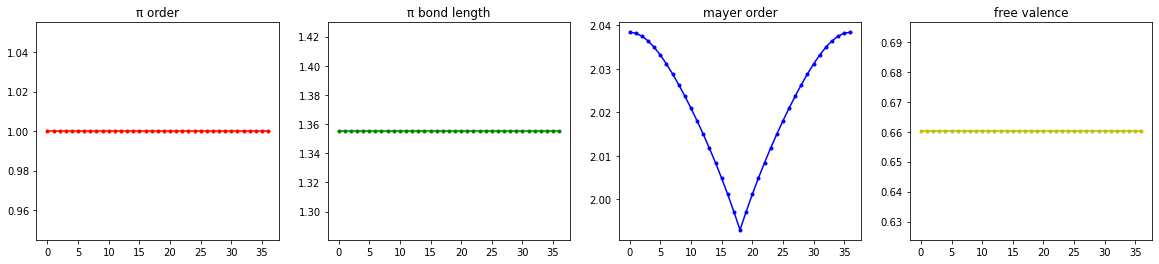

In [4]:
# 联苯键级键角图
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def get_wfnOrders(atom1,atom2):
    with open(r"C:\code\HFV\files\ethyleneScan\multiwfnRes.txt",'r',encoding='utf-8') as f:
        data=f.read()
    wfnOrders=re.findall(r'# +\d: +'+f'{atom1}'+'\(C \)    '+f'{atom2}'+'\(C \) +(\d.\d{8})',data)
    wfnOrders=np.array(wfnOrders,dtype=np.float32)
    return wfnOrders
def get_bondOrders(atom1,atom2):
    with open(r"C:\code\HFV\files\ethyleneScan\RES3.txt",'r',encoding='utf-8') as f:
        data=f.read()
    datas=data.split('----------------------------------------------------------------------')[1:]
    all_res=[]
    all_valence=[]
    for each in datas:
        res=re.search(f'{atom1}->{atom2}'+r',bond order:(-?\d.\d{4}),bond length:(-?\d.\d{4})',each)
        valence=re.search(r'free valence:(-?\d.\d{4})',each).groups()
        if res is not None:
            all_res.append(res.groups())
        else:
            all_res.append([0,0])
        all_valence.append(valence)
    bondOrders=pd.DataFrame(all_res,dtype=float).to_numpy()[:,0]
    bondLengths=pd.DataFrame(all_res,dtype=float).to_numpy()[:,1]
    atomValence=pd.DataFrame(all_valence,dtype=float).to_numpy().flatten()
    return bondOrders,bondLengths,atomValence
fig,a=plt.subplots(1,4,figsize=(20, 4))
around=4
bondOrders,bondLengths,atomValence=get_bondOrders(1,around)
a[0].set_title(f'π order')

a[0].plot(np.arange(len(bondOrders)),bondOrders,'r.-')
a[1].set_title(f'π bond length')
a[1].plot(np.arange(len(bondLengths)),bondLengths,'g.-')
wfnOrders=get_wfnOrders(1,around)
a[2].set_title(f'mayer order')
a[2].plot(np.arange(len(wfnOrders)),wfnOrders,'b.-')
a[3].set_title(f'free valence')
a[3].plot(np.arange(len(atomValence)),atomValence,'y.-')
# a[0].plot(np.arange(len(atomValence)),atomValence[::-1],'y.-')
# a[1].plot(np.arange(len(bondOrders)),bondOrders[::-1],'r.-')
# a[2].plot(np.arange(len(bondLengths)),bondLengths[::-1],'g.-')
# a[3].plot(np.arange(len(wfnOrders)),wfnOrders[::-1],'b.-')
# fig,a=plt.subplots(figsize=(14, 4))
# a.set_title('free valence 1')
# a.plot(np.arange(len(atomValence)),atomValence,'y.-')

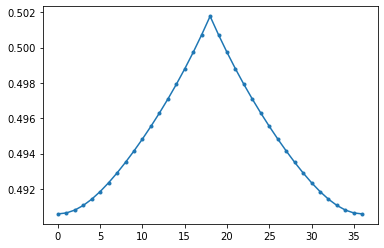

In [7]:
# plt.plot(np.arange(len(bondOrders)),bondOrders,'r.-')
# plt.plot(np.arange(len(wfnOrders)),wfnOrders,'b.-')
plt.plot(np.arange(len(wfnOrders)),bondOrders/wfnOrders,'.-')

In [79]:
wfnOrders.shape

(36,)

In [80]:
bondOrders.shape

(37,)